
# Adam Optimizer Assignment — Colab / NVIDIA T4

This notebook is a **self-contained assignment submission harness** for:

1. Reproducing Adam by hand and checking every quantity against PyTorch.
2. Disabling bias correction, plotting the first 20 steps, and measuring when the difference becomes negligible.
3. Logging update-to-weight ratio for every layer and marking where warmup stops changing it.
4. Comparing **cosine vs WSD** with schedules designed for 300 steps but both stopped at step 200.
5. Sweeping learning rate at widths **256, 512, and 1,024**, marking the minima, then extrapolating a starting LR for width 4,096.


## Colab runtime

Use:

**Runtime → Change runtime type → T4 GPU**

- hidden width: **2,048**
- linear depth: **6**
- input dimension: **256**
- output dimension: **64**
- roughly **17.4M parameters**
- batch size: **256**
- CUDA FP16 autocast enabled

The required width sweep still uses exactly **256 / 512 / 1,024**.

> Fair-comparison rule: identical initialization, identical step-matched batches, identical evaluation set, and separate LR tuning for cosine and WSD.

In [1]:

#@title 0. Imports, T4 check, and experiment configuration

import copy
import csv
import gc
import json
import math
import random
import shutil
from contextlib import nullcontext
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 2**30, 2))
else:
    print("WARNING: GPU is not enabled. In Colab choose Runtime → Change runtime type → T4 GPU.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

# T4-sized defaults for the main model experiments.
MODEL_WIDTH = 2048
MODEL_DEPTH = 6
IN_DIM = 256
OUT_DIM = 64
BATCH_SIZE = 256

# Assignment schedule settings.
TOTAL_SCHEDULE_STEPS = 300
STOP_STEP = 200
WARMUP_STEPS = 30
WSD_DECAY_STEPS = 60

RESULTS = Path("/content/adam_assignment_results") if Path("/content").exists() else Path("adam_assignment_results")
RESULTS.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

print("\nResults directory:", RESULTS)
print("Main-model profile:",
      f"width={MODEL_WIDTH}, depth={MODEL_DEPTH}, batch={BATCH_SIZE}, AMP={USE_AMP}")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory (GB): 14.56

Results directory: /content/adam_assignment_results
Main-model profile: width=2048, depth=6, batch=256, AMP=True



## 1. Reproduce Adam by hand

For a scalar parameter \(w\):

\[
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
\]

\[
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
\]

Bias correction:

\[
\hat m_t=\frac{m_t}{1-\beta_1^t},
\qquad
\hat v_t=\frac{v_t}{1-\beta_2^t}
\]

Update:

\[
\Delta w_t=\alpha\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon},
\qquad
w_t=w_{t-1}-\Delta w_t.
\]

We use one weight and five gradients and compare `m`, `v`, `m_hat`, `v_hat`, the step, and the resulting weight with PyTorch.


In [2]:
@dataclass
class ScalarAdamState:
    w: float
    m: float = 0.0
    v: float = 0.0

def adam_scalar_step(state, g, t, lr=1e-2, beta1=0.9, beta2=0.999,
                     eps=1e-8, bias_correction=True):
    m = beta1 * state.m + (1 - beta1) * g
    v = beta2 * state.v + (1 - beta2) * (g ** 2)

    if bias_correction:
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
    else:
        m_hat, v_hat = m, v

    step = lr * m_hat / (math.sqrt(v_hat) + eps)
    new_w = state.w - step
    state.w, state.m, state.v = new_w, m, v

    return {
        "t": t, "g": g, "m": m, "v": v,
        "m_hat": m_hat, "v_hat": v_hat,
        "step": step, "w_after": new_w,
    }

grads = [0.20, -0.10, 0.05, -0.30, 0.15]
w0 = 1.5
lr, beta1, beta2, eps = 1e-2, 0.9, 0.999, 1e-8

manual_state = ScalarAdamState(w0)
p = torch.tensor([w0], dtype=torch.float64, requires_grad=True)
optimizer = torch.optim.Adam([p], lr=lr, betas=(beta1, beta2), eps=eps)

part1_rows = []

for t, g in enumerate(grads, 1):
    manual = adam_scalar_step(
        manual_state, g, t,
        lr=lr, beta1=beta1, beta2=beta2, eps=eps,
        bias_correction=True,
    )

    optimizer.zero_grad(set_to_none=True)
    p.grad = torch.tensor([g], dtype=torch.float64)
    optimizer.step()

    state = optimizer.state[p]
    torch_m = state["exp_avg"].item()
    torch_v = state["exp_avg_sq"].item()

    # PyTorch stores m and v, so compute the corresponding corrected moments
    # from the PyTorch state for a direct check.
    torch_m_hat = torch_m / (1 - beta1 ** t)
    torch_v_hat = torch_v / (1 - beta2 ** t)

    row = {
        **manual,
        "torch_m": torch_m,
        "torch_v": torch_v,
        "torch_m_hat": torch_m_hat,
        "torch_v_hat": torch_v_hat,
        "torch_w_after": p.item(),
        "abs_weight_error": abs(p.item() - manual["w_after"]),
    }
    part1_rows.append(row)

# Display a compact table.
headers = ["t","g","m","v","m_hat","v_hat","step","w_after","torch_w_after","abs_weight_error"]
print(" | ".join(f"{h:>16}" for h in headers))
print("-" * 180)
for r in part1_rows:
    print(" | ".join(
        f"{r[h]:16.10g}" if h != "t" else f"{r[h]:16d}"
        for h in headers
    ))

# Strong checks against PyTorch.
for r in part1_rows:
    assert abs(r["m"] - r["torch_m"]) < 1e-12
    assert abs(r["v"] - r["torch_v"]) < 1e-12
    assert abs(r["m_hat"] - r["torch_m_hat"]) < 1e-12
    assert abs(r["v_hat"] - r["torch_v_hat"]) < 1e-12
    assert r["abs_weight_error"] < 1e-10

with open(RESULTS / "part1_adam_hand_vs_torch.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=part1_rows[0].keys())
    writer.writeheader()
    writer.writerows(part1_rows)

print("\nPASS — manual Adam and PyTorch agree to floating-point precision.")


               t |                g |                m |                v |            m_hat |            v_hat |             step |          w_after |    torch_w_after | abs_weight_error
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
               1 |              0.2 |             0.02 |            4e-05 |              0.2 |             0.04 |     0.0099999995 |      1.490000001 |      1.490000001 |                0
               2 |             -0.1 |            0.008 |        4.996e-05 |    0.04210526316 |    0.02499249625 |   0.002663370228 |       1.48733663 |       1.48733663 |                0
               3 |             0.05 |           0.0122 |     5.241004e-05 |    0.04501845018 |      0.017487495 |   0.003404291225 |      1.483932339 |      1.483932339 |                0
               4 |             -0.3 |         -0.01902 |    0.00014


## 2. Disable bias correction

The plot remains limited to the first 20 updates, but a separate scalar calculation is allowed to continue beyond 20 so that we can report an actual crossing step.


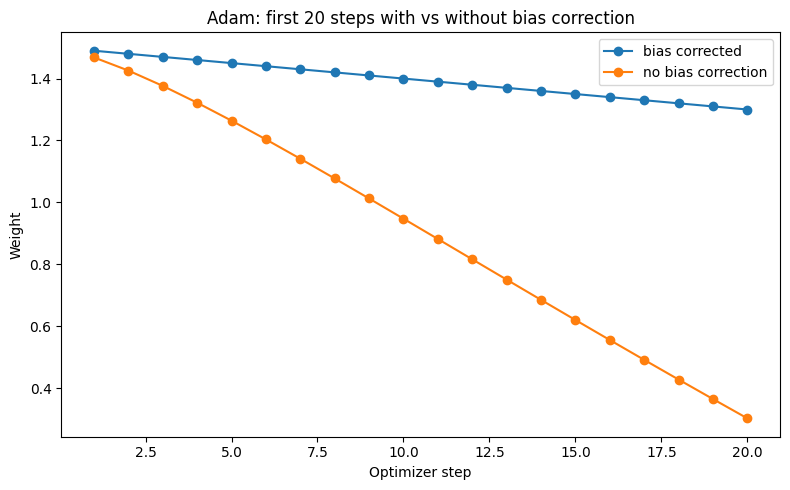

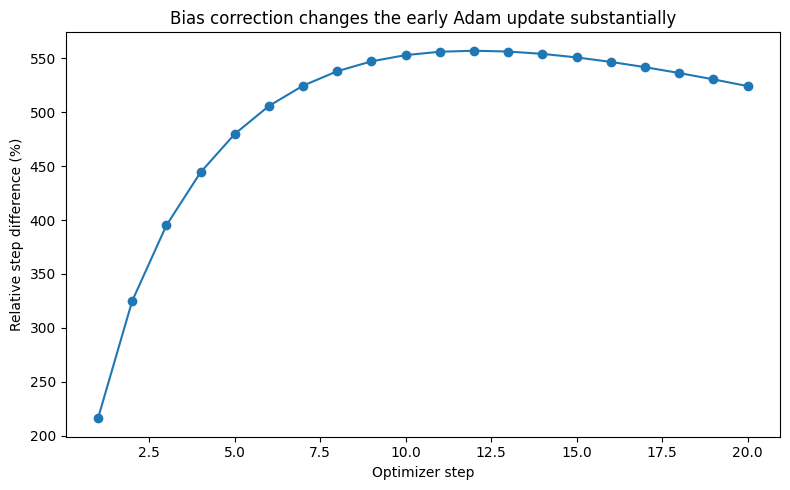

Definition of 'stops mattering': relative update difference < 1.0% and stays below it.
Settling step: 3925
Relative difference at step 20: 524.09%


In [3]:
BIAS_THRESHOLD = 0.01  # 1%

corr = ScalarAdamState(1.5)
uncorr = ScalarAdamState(1.5)

part2_rows = []
for t in range(1, 21):
    g = 0.20
    a = adam_scalar_step(corr, g, t, bias_correction=True)
    b = adam_scalar_step(uncorr, g, t, bias_correction=False)

    rel_diff = abs(a["step"] - b["step"]) / max(abs(a["step"]), 1e-15)
    part2_rows.append({
        "step": t,
        "weight_bias_corrected": a["w_after"],
        "weight_no_bias_correction": b["w_after"],
        "step_bias_corrected": a["step"],
        "step_no_bias_correction": b["step"],
        "relative_step_difference": rel_diff,
    })

# Find the first step at which the constant-gradient update difference is <1%
# and remains below that threshold. We search beyond the requested 20-step plot.
corr_long = ScalarAdamState(1.5)
uncorr_long = ScalarAdamState(1.5)
settling_step = None
long_diffs = []

for t in range(1, 10001):
    a = adam_scalar_step(corr_long, 0.20, t, bias_correction=True)
    b = adam_scalar_step(uncorr_long, 0.20, t, bias_correction=False)
    rel_diff = abs(a["step"] - b["step"]) / max(abs(a["step"]), 1e-15)
    long_diffs.append(rel_diff)

# "and stays there" is verified over the remainder of the 10k-step window.
for i, d in enumerate(long_diffs):
    if d < BIAS_THRESHOLD and max(long_diffs[i:]) < BIAS_THRESHOLD:
        settling_step = i + 1
        break

with open(RESULTS / "part2_bias_correction.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=part2_rows[0].keys())
    writer.writeheader()
    writer.writerows(part2_rows)

steps = [r["step"] for r in part2_rows]

plt.figure(figsize=(8,5))
plt.plot(steps, [r["weight_bias_corrected"] for r in part2_rows], marker="o", label="bias corrected")
plt.plot(steps, [r["weight_no_bias_correction"] for r in part2_rows], marker="o", label="no bias correction")
plt.xlabel("Optimizer step")
plt.ylabel("Weight")
plt.title("Adam: first 20 steps with vs without bias correction")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "part2_weights.png", dpi=180)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(steps, [100*r["relative_step_difference"] for r in part2_rows], marker="o")
plt.xlabel("Optimizer step")
plt.ylabel("Relative step difference (%)")
plt.title("Bias correction changes the early Adam update substantially")
plt.tight_layout()
plt.savefig(RESULTS / "part2_relative_difference_first20.png", dpi=180)
plt.show()

print(f"Definition of 'stops mattering': relative update difference < {100*BIAS_THRESHOLD:.1f}% and stays below it.")
print("Settling step:", settling_step)
print(f"Relative difference at step 20: {100*part2_rows[-1]['relative_step_difference']:.2f}%")



## 3. Update-to-weight ratio for every layer

For each parameter tensor \(W\):

\[
\text{update-to-weight ratio}
=
\frac{\|\Delta W\|_2}{\|W\|_2}.
\]


In [4]:
class DeepMLP(nn.Module):
    def __init__(self, width=2048, depth=6, in_dim=256, out_dim=64):
        super().__init__()
        assert depth >= 3

        layers = [nn.Linear(in_dim, width), nn.GELU()]
        for _ in range(depth - 2):
            layers += [nn.Linear(width, width), nn.GELU()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class SyntheticTeacher:
    def __init__(self, in_dim=IN_DIM, hidden=512, out_dim=OUT_DIM, seed=1234):
        gen = torch.Generator(device="cpu").manual_seed(seed)
        self.W1 = torch.randn(in_dim, hidden, generator=gen) / math.sqrt(in_dim)
        self.b1 = torch.randn(hidden, generator=gen) * 0.1
        self.W2 = torch.randn(hidden, out_dim, generator=gen) / math.sqrt(hidden)
        self.b2 = torch.randn(out_dim, generator=gen) * 0.1

    def target_cpu(self, x_cpu):
        return F.gelu(x_cpu @ self.W1 + self.b1) @ self.W2 + self.b2

TEACHER = SyntheticTeacher()

def make_batch(batch_size, step_seed, device=DEVICE):
    gen = torch.Generator(device="cpu").manual_seed(step_seed)
    x_cpu = torch.randn(batch_size, IN_DIM, generator=gen)
    y_cpu = TEACHER.target_cpu(x_cpu)
    return x_cpu.to(device, non_blocking=True), y_cpu.to(device, non_blocking=True)

def amp_context():
    if USE_AMP:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()

def parameter_count(model):
    return sum(p.numel() for p in model.parameters())

def fixed_eval(model, n=4096, seed=999):
    model.eval()
    losses = []
    with torch.no_grad():
        for offset in range(0, n, BATCH_SIZE):
            bs = min(BATCH_SIZE, n - offset)
            x, y = make_batch(bs, seed + offset)
            with amp_context():
                pred = model(x)
                loss = F.mse_loss(pred.float(), y.float())
            losses.append(loss.item() * bs)
    model.train()
    return sum(losses) / n

model_probe = DeepMLP(MODEL_WIDTH, MODEL_DEPTH).to(DEVICE)
print(f"Main model parameters: {parameter_count(model_probe):,}")
del model_probe
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Main model parameters: 17,442,880


/tmp/ipykernel_2584/1439399391.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


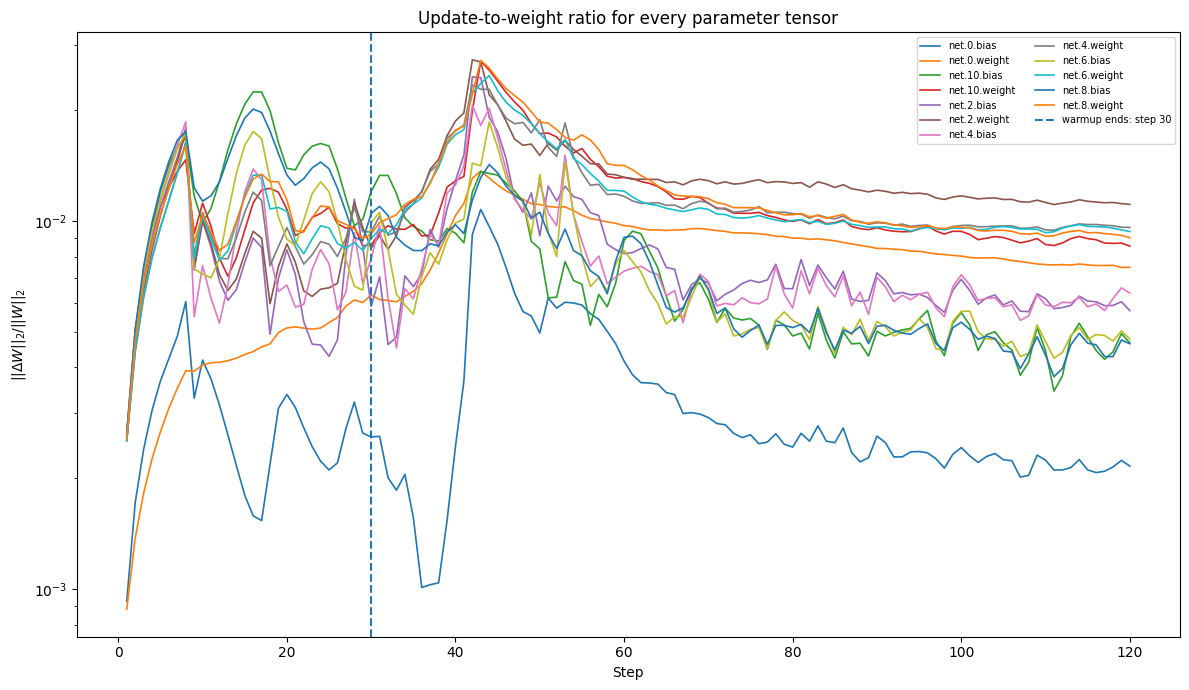

Warmup stops directly changing the LR at step 30.
After this line, changes in the ratio come from gradients, Adam state, and parameter norms—not from an increasing warmup LR.


In [5]:
seed_everything(7)
model = DeepMLP(MODEL_WIDTH, MODEL_DEPTH).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

BASE_LR = 1e-3
PART3_STEPS = 120
part3_rows = []

for step in range(1, PART3_STEPS + 1):
    lr_mult = min(1.0, step / WARMUP_STEPS)
    current_lr = BASE_LR * lr_mult
    for group in optimizer.param_groups:
        group["lr"] = current_lr

    x, y = make_batch(BATCH_SIZE, 30_000 + step)

    optimizer.zero_grad(set_to_none=True)
    with amp_context():
        pred = model(x)
        loss = F.mse_loss(pred.float(), y.float())

    scaler.scale(loss).backward()

    # Snapshot just before the update.
    before = {name: p.detach().clone() for name, p in model.named_parameters()}

    scaler.step(optimizer)
    scaler.update()

    for name, p in model.named_parameters():
        delta = p.detach() - before[name]
        w_norm = before[name].float().norm().item()
        u_norm = delta.float().norm().item()
        part3_rows.append({
            "step": step,
            "parameter": name,
            "loss": loss.item(),
            "lr": current_lr,
            "weight_norm": w_norm,
            "update_norm": u_norm,
            "update_to_weight_ratio": u_norm / max(w_norm, 1e-12),
        })

with open(RESULTS / "part3_update_weight_ratio.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=part3_rows[0].keys())
    writer.writeheader()
    writer.writerows(part3_rows)

plt.figure(figsize=(12,7))
for name in sorted({r["parameter"] for r in part3_rows}):
    rr = [r for r in part3_rows if r["parameter"] == name]
    plt.plot(
        [r["step"] for r in rr],
        [r["update_to_weight_ratio"] for r in rr],
        label=name,
        linewidth=1.2,
    )
plt.axvline(WARMUP_STEPS, linestyle="--", label=f"warmup ends: step {WARMUP_STEPS}")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel(r"$||\Delta W||_2 / ||W||_2$")
plt.title("Update-to-weight ratio for every parameter tensor")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS / "part3_update_weight_ratio.png", dpi=180)
plt.show()

print(f"Warmup stops directly changing the LR at step {WARMUP_STEPS}.")
print("After this line, changes in the ratio come from gradients, Adam state, and parameter norms—not from an increasing warmup LR.")



## 4. Cosine vs WSD — schedules planned for 300 steps, both stopped at 200

Each schedule gets a small independent LR sweep first. Then the final two models:

- start from the exact same weights,
- see the exact same batch at every matching step,
- use the exact same optimizer settings,
- are both stopped at step 200,
- and are evaluated on the same fixed evaluation set.

WSD is configured as:

- warmup: steps 1–30
- stable plateau: through step 240
- decay: final 60 steps of the *planned* 300-step run

Therefore at the unexpected stop at step 200, WSD has not started its decay phase.


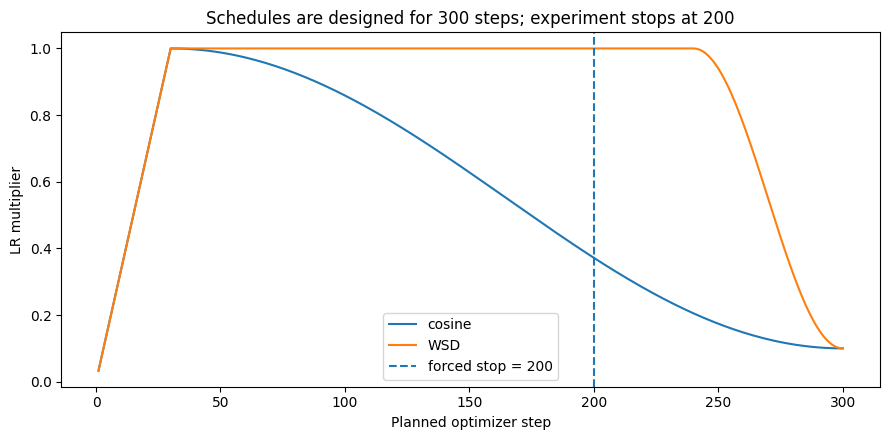

In [6]:
def cosine_multiplier(step, total_steps=300, warmup_steps=30, min_ratio=0.1):
    if step <= warmup_steps:
        return step / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    progress = min(max(progress, 0.0), 1.0)
    c = 0.5 * (1 + math.cos(math.pi * progress))
    return min_ratio + (1 - min_ratio) * c

def wsd_multiplier(step, total_steps=300, warmup_steps=30, decay_steps=60, min_ratio=0.1):
    stable_end = total_steps - decay_steps
    if step <= warmup_steps:
        return step / warmup_steps
    if step <= stable_end:
        return 1.0
    progress = (step - stable_end) / decay_steps
    progress = min(max(progress, 0.0), 1.0)
    c = 0.5 * (1 + math.cos(math.pi * progress))
    return min_ratio + (1 - min_ratio) * c

xs = np.arange(1, TOTAL_SCHEDULE_STEPS + 1)
plt.figure(figsize=(9,4.5))
plt.plot(xs, [cosine_multiplier(int(x)) for x in xs], label="cosine")
plt.plot(xs, [wsd_multiplier(int(x)) for x in xs], label="WSD")
plt.axvline(STOP_STEP, linestyle="--", label="forced stop = 200")
plt.xlabel("Planned optimizer step")
plt.ylabel("LR multiplier")
plt.title("Schedules are designed for 300 steps; experiment stops at 200")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "part4_schedule_shapes.png", dpi=180)
plt.show()


In [7]:
def train_schedule(schedule_name, peak_lr, init_state, width=MODEL_WIDTH, depth=MODEL_DEPTH,
                   stop_step=STOP_STEP, record_curve=False, seed=11):
    seed_everything(seed)

    model = DeepMLP(width=width, depth=depth).to(DEVICE)
    model.load_state_dict(copy.deepcopy(init_state))

    opt = torch.optim.AdamW(model.parameters(), lr=peak_lr, weight_decay=0.01)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = []

    for step in range(1, stop_step + 1):
        if schedule_name == "cosine":
            mult = cosine_multiplier(step, TOTAL_SCHEDULE_STEPS, WARMUP_STEPS)
        elif schedule_name == "wsd":
            mult = wsd_multiplier(step, TOTAL_SCHEDULE_STEPS, WARMUP_STEPS, WSD_DECAY_STEPS)
        else:
            raise ValueError(schedule_name)

        lr_now = peak_lr * mult
        for group in opt.param_groups:
            group["lr"] = lr_now

        # Same batch seed for both schedules at every corresponding step.
        x, y = make_batch(BATCH_SIZE, 40_000 + step)

        opt.zero_grad(set_to_none=True)
        with amp_context():
            pred = model(x)
            loss = F.mse_loss(pred.float(), y.float())

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        if record_curve:
            history.append({
                "schedule": schedule_name,
                "step": step,
                "train_loss": loss.item(),
                "lr": lr_now,
            })

    eval_loss = fixed_eval(model)

    del model, opt, scaler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return eval_loss, history


In [8]:

#@title 4C. Tune peak LR separately for cosine and WSD

# A compact but meaningful T4 tuning grid.
SCHEDULE_LR_GRID = [2e-4, 4e-4, 8e-4, 1.6e-3, 3.2e-3]

seed_everything(11)
initial_model = DeepMLP(MODEL_WIDTH, MODEL_DEPTH)
shared_init_state = copy.deepcopy(initial_model.state_dict())
del initial_model

schedule_tuning = []

for schedule in ["cosine", "wsd"]:
    for peak_lr in SCHEDULE_LR_GRID:
        eval_loss, _ = train_schedule(
            schedule,
            peak_lr,
            shared_init_state,
            record_curve=False,
        )
        schedule_tuning.append({
            "schedule": schedule,
            "peak_lr": peak_lr,
            "eval_loss_at_200": eval_loss,
        })
        print(f"{schedule:7s} peak_lr={peak_lr:.4g}  eval_loss@200={eval_loss:.6f}")

best_cos = min(
    [r for r in schedule_tuning if r["schedule"] == "cosine"],
    key=lambda r: r["eval_loss_at_200"],
)
best_wsd = min(
    [r for r in schedule_tuning if r["schedule"] == "wsd"],
    key=lambda r: r["eval_loss_at_200"],
)

print("\nBest cosine:", best_cos)
print("Best WSD:   ", best_wsd)

with open(RESULTS / "part4_schedule_tuning.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=schedule_tuning[0].keys())
    writer.writeheader()
    writer.writerows(schedule_tuning)


/tmp/ipykernel_2584/354656180.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


cosine  peak_lr=0.0002  eval_loss@200=0.113028
cosine  peak_lr=0.0004  eval_loss@200=0.102380
cosine  peak_lr=0.0008  eval_loss@200=0.095765
cosine  peak_lr=0.0016  eval_loss@200=0.092943
cosine  peak_lr=0.0032  eval_loss@200=0.342591
wsd     peak_lr=0.0002  eval_loss@200=0.110744
wsd     peak_lr=0.0004  eval_loss@200=0.102370
wsd     peak_lr=0.0008  eval_loss@200=0.101491
wsd     peak_lr=0.0016  eval_loss@200=0.107471
wsd     peak_lr=0.0032  eval_loss@200=0.342626

Best cosine: {'schedule': 'cosine', 'peak_lr': 0.0016, 'eval_loss_at_200': 0.09294281667098403}
Best WSD:    {'schedule': 'wsd', 'peak_lr': 0.0008, 'eval_loss_at_200': 0.10149142052978277}


/tmp/ipykernel_2584/354656180.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


{
  "cosine_best_peak_lr": 0.0016,
  "wsd_best_peak_lr": 0.0008,
  "cosine_eval_loss_at_step_200": 0.09294281667098403,
  "wsd_eval_loss_at_step_200": 0.10149142052978277,
  "model_to_keep": "cosine"
}


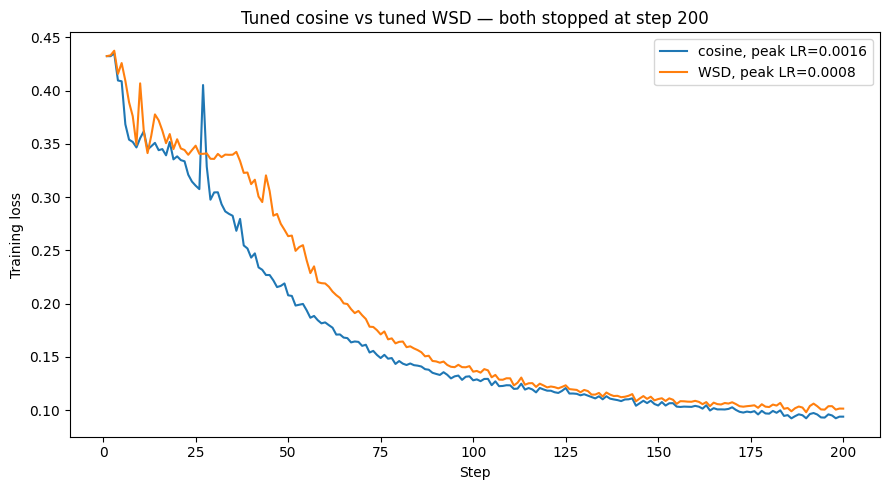

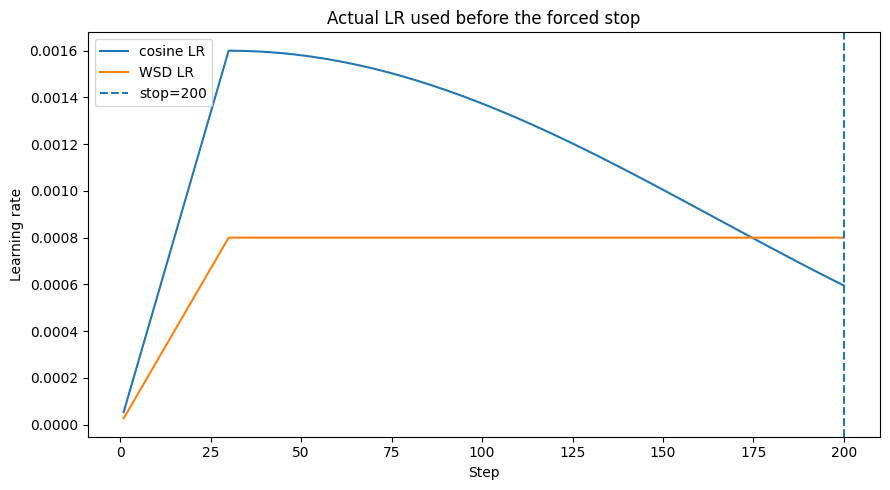

In [9]:

#@title 4D. Final tuned cosine vs tuned WSD comparison

cos_eval, cos_history = train_schedule(
    "cosine", best_cos["peak_lr"], shared_init_state, record_curve=True
)
wsd_eval, wsd_history = train_schedule(
    "wsd", best_wsd["peak_lr"], shared_init_state, record_curve=True
)

keep_schedule = "cosine" if cos_eval < wsd_eval else "WSD"

part4_result = {
    "cosine_best_peak_lr": best_cos["peak_lr"],
    "wsd_best_peak_lr": best_wsd["peak_lr"],
    "cosine_eval_loss_at_step_200": cos_eval,
    "wsd_eval_loss_at_step_200": wsd_eval,
    "model_to_keep": keep_schedule,
}

print(json.dumps(part4_result, indent=2))

with open(RESULTS / "part4_result.json", "w") as f:
    json.dump(part4_result, f, indent=2)

all_hist = cos_history + wsd_history
with open(RESULTS / "part4_final_curves.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=all_hist[0].keys())
    writer.writeheader()
    writer.writerows(all_hist)

plt.figure(figsize=(9,5))
plt.plot(
    [r["step"] for r in cos_history],
    [r["train_loss"] for r in cos_history],
    label=f"cosine, peak LR={best_cos['peak_lr']:.3g}",
)
plt.plot(
    [r["step"] for r in wsd_history],
    [r["train_loss"] for r in wsd_history],
    label=f"WSD, peak LR={best_wsd['peak_lr']:.3g}",
)
plt.xlabel("Step")
plt.ylabel("Training loss")
plt.title("Tuned cosine vs tuned WSD — both stopped at step 200")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "part4_loss_cosine_vs_wsd.png", dpi=180)
plt.show()

plt.figure(figsize=(9,5))
plt.plot([r["step"] for r in cos_history], [r["lr"] for r in cos_history], label="cosine LR")
plt.plot([r["step"] for r in wsd_history], [r["lr"] for r in wsd_history], label="WSD LR")
plt.axvline(STOP_STEP, linestyle="--", label="stop=200")
plt.xlabel("Step")
plt.ylabel("Learning rate")
plt.title("Actual LR used before the forced stop")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "part4_lr_cosine_vs_wsd.png", dpi=180)
plt.show()



## 5. Learning-rate sweep at widths 256, 512, and 1,024

The model architecture stays the same except for hidden width.

For each width, we sweep a broad log-spaced LR grid and plot held-out loss against peak LR. The minimum for each width is marked with a star.

Then we fit the empirical relation

\[
\eta^*(d)=Cd^a
\]

through the three measured optima and evaluate the fit at width 4,096.

This is an **extrapolated starting point**, not a claim that the 4,096 optimum has been directly measured.


In [10]:

#@title 5A. Width/LR sweep utilities

SWEEP_WIDTHS = [256, 512, 1024]
SWEEP_LRS = [5e-5, 1e-4, 2e-4, 4e-4, 8e-4, 1.6e-3, 3.2e-3, 6.4e-3, 1.28e-2]
SWEEP_STEPS = 120

def train_width_lr(width, peak_lr, steps=SWEEP_STEPS, depth=MODEL_DEPTH):
    # Same initialization seed for all LRs at a given width.
    seed_everything(1000 + width)
    model = DeepMLP(width=width, depth=depth).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=peak_lr, weight_decay=0.01)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    warmup = max(10, int(0.1 * steps))

    for step in range(1, steps + 1):
        mult = cosine_multiplier(step, total_steps=steps, warmup_steps=warmup, min_ratio=0.1)
        lr_now = peak_lr * mult
        for group in opt.param_groups:
            group["lr"] = lr_now

        # Same data at each matching step for every LR and width.
        x, y = make_batch(BATCH_SIZE, 50_000 + step)

        opt.zero_grad(set_to_none=True)
        with amp_context():
            pred = model(x)
            loss = F.mse_loss(pred.float(), y.float())

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

    eval_loss = fixed_eval(model)

    del model, opt, scaler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return eval_loss



--- width 256 ---


/tmp/ipykernel_2584/4202904629.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


lr=   5e-05  loss=0.402771
lr=  0.0001  loss=0.344627
lr=  0.0002  loss=0.338610
lr=  0.0004  loss=0.337173
lr=  0.0008  loss=0.329589
lr=  0.0016  loss=0.285012
lr=  0.0032  loss=0.226961
lr=  0.0064  loss=0.220511
lr=  0.0128  loss=0.250722

--- width 512 ---
lr=   5e-05  loss=0.341915
lr=  0.0001  loss=0.338980
lr=  0.0002  loss=0.337231
lr=  0.0004  loss=0.333746
lr=  0.0008  loss=0.268196
lr=  0.0016  loss=0.205216
lr=  0.0032  loss=0.234650
lr=  0.0064  loss=0.209532
lr=  0.0128  loss=0.359110

--- width 1024 ---
lr=   5e-05  loss=0.339520
lr=  0.0001  loss=0.337167
lr=  0.0002  loss=0.331901
lr=  0.0004  loss=0.226133
lr=  0.0008  loss=0.175895
lr=  0.0016  loss=0.228880
lr=  0.0032  loss=0.272539
lr=  0.0064  loss=0.345669
lr=  0.0128  loss=0.548944


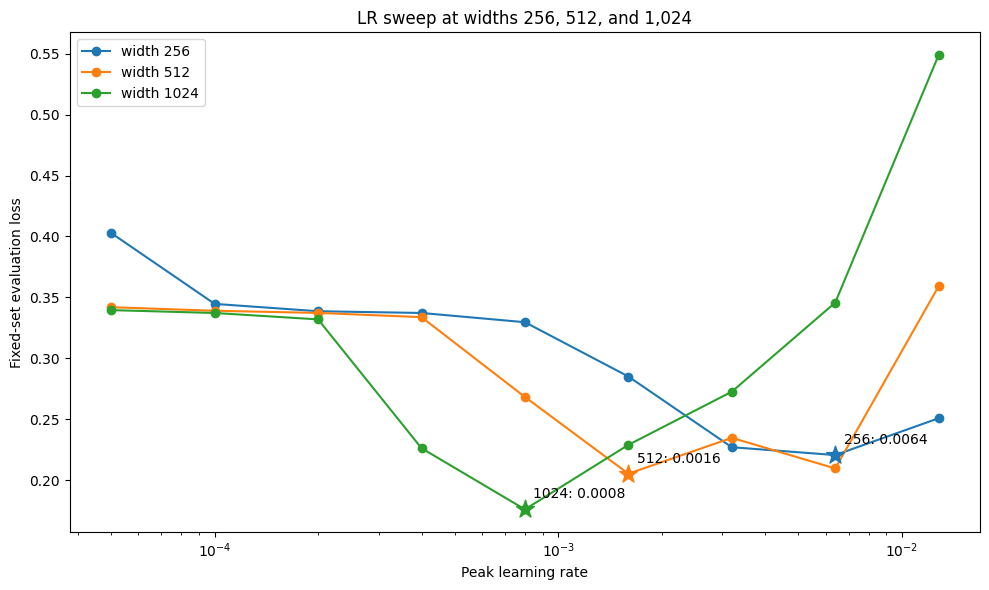


Measured minima:
256 {'width': 256, 'learning_rate': 0.0064, 'eval_loss': 0.2205106671899557}
512 {'width': 512, 'learning_rate': 0.0016, 'eval_loss': 0.20521576330065727}
1024 {'width': 1024, 'learning_rate': 0.0008, 'eval_loss': 0.17589451000094414}


In [11]:

#@title 5B. Run the required LR sweep and mark all three minima

part5_rows = []

for width in SWEEP_WIDTHS:
    print(f"\n--- width {width} ---")
    for peak_lr in SWEEP_LRS:
        eval_loss = train_width_lr(width, peak_lr)
        row = {
            "width": width,
            "learning_rate": peak_lr,
            "eval_loss": eval_loss,
        }
        part5_rows.append(row)
        print(f"lr={peak_lr:8.5g}  loss={eval_loss:.6f}")

with open(RESULTS / "part5_lr_sweep.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=part5_rows[0].keys())
    writer.writeheader()
    writer.writerows(part5_rows)

best_by_width = {}
for width in SWEEP_WIDTHS:
    candidates = [r for r in part5_rows if r["width"] == width]
    best_by_width[width] = min(candidates, key=lambda r: r["eval_loss"])

plt.figure(figsize=(10,6))
for width in SWEEP_WIDTHS:
    rr = sorted(
        [r for r in part5_rows if r["width"] == width],
        key=lambda r: r["learning_rate"],
    )
    plt.plot(
        [r["learning_rate"] for r in rr],
        [r["eval_loss"] for r in rr],
        marker="o",
        label=f"width {width}",
    )

    best = best_by_width[width]
    plt.scatter(
        [best["learning_rate"]],
        [best["eval_loss"]],
        marker="*",
        s=180,
        zorder=5,
    )
    plt.annotate(
        f"{width}: {best['learning_rate']:.3g}",
        (best["learning_rate"], best["eval_loss"]),
        textcoords="offset points",
        xytext=(6,8),
    )

plt.xscale("log")
plt.xlabel("Peak learning rate")
plt.ylabel("Fixed-set evaluation loss")
plt.title("LR sweep at widths 256, 512, and 1,024")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "part5_lr_sweep.png", dpi=180)
plt.show()

print("\nMeasured minima:")
for width in SWEEP_WIDTHS:
    print(width, best_by_width[width])


In [12]:

#@title 5C. Extrapolate a starting LR for width 4,096

width_arr = np.array(SWEEP_WIDTHS, dtype=np.float64)
best_lr_arr = np.array(
    [best_by_width[w]["learning_rate"] for w in SWEEP_WIDTHS],
    dtype=np.float64,
)

# log(lr*) = intercept + slope*log(width)
slope, intercept = np.polyfit(np.log(width_arr), np.log(best_lr_arr), 1)
recommended_lr_4096 = float(np.exp(intercept + slope * np.log(4096)))

grid_edges = {min(SWEEP_LRS), max(SWEEP_LRS)}
edge_hits = sum(best_by_width[w]["learning_rate"] in grid_edges for w in SWEEP_WIDTHS)

if edge_hits == 0:
    confidence = "moderate"
elif edge_hits == 1:
    confidence = "low-to-moderate"
else:
    confidence = "low"

part5_result = {
    "best_by_width": {
        str(w): best_by_width[w] for w in SWEEP_WIDTHS
    },
    "power_law_slope": float(slope),
    "recommended_lr_width_4096": recommended_lr_4096,
    "confidence": confidence,
    "edge_minima_count": int(edge_hits),
}

with open(RESULTS / "part5_result.json", "w") as f:
    json.dump(part5_result, f, indent=2)

print(json.dumps(part5_result, indent=2))

if edge_hits:
    print("\nWARNING: at least one minimum is on the edge of the LR grid.")
    print("Expand the grid before treating the 4,096 extrapolation as final.")
else:
    print("\nAll three observed minima are interior to the LR grid.")


{
  "best_by_width": {
    "256": {
      "width": 256,
      "learning_rate": 0.0064,
      "eval_loss": 0.2205106671899557
    },
    "512": {
      "width": 512,
      "learning_rate": 0.0016,
      "eval_loss": 0.20521576330065727
    },
    "1024": {
      "width": 1024,
      "learning_rate": 0.0008,
      "eval_loss": 0.17589451000094414
    }
  },
  "power_law_slope": -1.4999999999999993,
  "recommended_lr_width_4096": 8.908987181403446e-05,
  "confidence": "moderate",
  "edge_minima_count": 0
}

All three observed minima are interior to the LR grid.



## 6. Generate the final `README.md`

Run this **after all previous sections**.

The cell inserts the actual measured values into a detailed submission README instead of leaving placeholders. This prevents accidental fabrication of the cosine/WSD losses or LR minima.


In [13]:

#@title 6A. Build a submission-ready README from the measured results

p1_last = part1_rows[-1]
p2_20 = part2_rows[-1]

readme_text = f"""# Adam Optimizer Assignment

## Experimental setup

All GPU experiments were run with PyTorch on `{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}`.

The main T4 model used for the update-ratio and scheduler experiments has:

- width: **{MODEL_WIDTH:,}**
- linear depth: **{MODEL_DEPTH}**
- input dimension: **{IN_DIM}**
- output dimension: **{OUT_DIM}**
- batch size: **{BATCH_SIZE}**
- mixed precision: **{USE_AMP}**

The learning-rate scaling experiment uses the assignment-required widths **256, 512, and 1,024**.

A/B comparisons use identical initialization, step-matched data, optimizer settings, and evaluation data. Cosine and WSD are tuned independently before the final comparison.

---

## 1. Adam reproduced by hand

For gradient `g_t`, Adam computes

`m_t = beta1*m_(t-1) + (1-beta1)*g_t`

`v_t = beta2*v_(t-1) + (1-beta2)*g_t^2`

with bias-corrected moments

`m_hat_t = m_t / (1-beta1^t)`

`v_hat_t = v_t / (1-beta2^t)`.

The parameter update is

`w_t = w_(t-1) - lr * m_hat_t / (sqrt(v_hat_t) + eps)`.

I used one scalar weight, initial value **1.5**, with gradients:

`[0.20, -0.10, 0.05, -0.30, 0.15]`

and Adam settings `lr=0.01`, `beta1=0.9`, `beta2=0.999`, `eps=1e-8`.

| t | g | m | v | m_hat | v_hat | step | weight after |
|---:|---:|---:|---:|---:|---:|---:|---:|
""" + "\n".join(
    f"| {r['t']} | {r['g']:.5f} | {r['m']:.8f} | {r['v']:.10f} | {r['m_hat']:.8f} | {r['v_hat']:.10f} | {r['step']:.8f} | {r['w_after']:.8f} |"
    for r in part1_rows
) + f"""

PyTorch reproduced the same moment values and final weights to floating-point precision. The largest weight disagreement across the five updates was **{max(r['abs_weight_error'] for r in part1_rows):.3e}**.

---

## 2. Effect of disabling bias correction

I plotted the first twenty scalar Adam updates with and without bias correction.

I define “stops mattering” as the first step after which the relative update-magnitude difference is **below 1% and remains below 1%**.

Under that definition:

- relative difference at step 20: **{100*p2_20['relative_step_difference']:.2f}%**
- first persistent <1% step: **{settling_step}**

The result shows why bias correction is primarily an early-training correction but can remain numerically relevant much longer than a 20-step plot suggests, especially because `beta2=0.999` gives the second moment a long time constant.

Plots:

- `part2_weights.png`
- `part2_relative_difference_first20.png`

---

## 3. Update-to-weight ratio

For every parameter tensor I logged

`||Delta W||_2 / ||W||_2`

at every optimizer step.

The run uses linear warmup for **{WARMUP_STEPS} steps**, so the scheduler stops increasing the learning rate at **step {WARMUP_STEPS}**. The plot shows the same boundary in the parameter-update ratios. After that point, variation in the ratio comes from gradients, Adam's moving moments, and the changing parameter norms rather than from an increasing warmup LR.

Plot:

- `part3_update_weight_ratio.png`

Raw log:

- `part3_update_weight_ratio.csv`

---

## 4. Cosine vs WSD with an unexpected stop at step 200

Both schedules are designed for **300 steps**, but both runs are stopped at **step 200**.

The WSD schedule uses:

- warmup: first {WARMUP_STEPS} steps
- stable phase: through step {TOTAL_SCHEDULE_STEPS - WSD_DECAY_STEPS}
- decay: final {WSD_DECAY_STEPS} planned steps

Therefore WSD has **not started its decay phase** when training is interrupted at step 200, while cosine has already been decaying.

Crucially, I tuned the peak LR separately for each schedule before comparing them.

Measured result:

| Schedule | Tuned peak LR | Eval loss at step 200 |
|---|---:|---:|
| Cosine | {best_cos['peak_lr']:.6g} | {cos_eval:.8f} |
| WSD | {best_wsd['peak_lr']:.6g} | {wsd_eval:.8f} |

**Model I would keep: {keep_schedule}.**

That decision is based on the lower fixed-set evaluation loss after tuning both sides, rather than on an assumed schedule advantage.

Plots:

- `part4_schedule_shapes.png`
- `part4_loss_cosine_vs_wsd.png`
- `part4_lr_cosine_vs_wsd.png`

---

## 5. Learning-rate sweep across model width

I swept learning rate independently at widths **256, 512, and 1,024**.

Measured minima:

| Width | Best LR | Eval loss |
|---:|---:|---:|
| 256 | {best_by_width[256]['learning_rate']:.6g} | {best_by_width[256]['eval_loss']:.8f} |
| 512 | {best_by_width[512]['learning_rate']:.6g} | {best_by_width[512]['eval_loss']:.8f} |
| 1,024 | {best_by_width[1024]['learning_rate']:.6g} | {best_by_width[1024]['eval_loss']:.8f} |

I fit an empirical power law

`lr*(width) = C * width^a`

through the three measured optima.

- fitted exponent `a`: **{slope:.4f}**
- extrapolated starting LR at width 4,096: **{recommended_lr_4096:.6g}**
- confidence: **{confidence}**

**I would start width 4,096 at approximately {recommended_lr_4096:.6g}.**

My confidence is **{confidence}** because this is an extrapolation from only three measured widths, not a direct width-4,096 sweep. Before committing an expensive training run I would perform a narrow local sweep around this predicted value.

{"At least one observed minimum lies on the boundary of the LR grid, so I would expand the sweep before accepting the extrapolation." if edge_hits else "All three minima are interior to the tested LR grid, which makes the trend more credible, but the 4,096 value is still an extrapolation."}

Plot:

- `part5_lr_sweep.png`

---

## Fair-comparison checklist

1. Same initialization for paired A/B comparisons.
2. Same data at corresponding steps.
3. Same number of optimizer steps.
4. Same evaluation set and metric.
5. Same optimizer family and non-tested hyperparameters.
6. Cosine and WSD each receive independent LR tuning.
7. LR sweep minima are checked for boundary hits.
8. The width-4,096 value is reported as an extrapolated starting point, not as a directly measured optimum.

This matters because an optimizer or schedule claim is not meaningful if one side is tuned and the other is not.
"""

readme_path = RESULTS / "README.md"
readme_path.write_text(readme_text)

print(readme_text)
print("\nSaved:", readme_path)


# Adam Optimizer Assignment

## Experimental setup

All GPU experiments were run with PyTorch on `Tesla T4`.

The main T4 model used for the update-ratio and scheduler experiments has:

- width: **2,048**
- linear depth: **6**
- input dimension: **256**
- output dimension: **64**
- batch size: **256**
- mixed precision: **True**

The learning-rate scaling experiment uses the assignment-required widths **256, 512, and 1,024**.

A/B comparisons use identical initialization, step-matched data, optimizer settings, and evaluation data. Cosine and WSD are tuned independently before the final comparison.

---

## 1. Adam reproduced by hand

For gradient `g_t`, Adam computes

`m_t = beta1*m_(t-1) + (1-beta1)*g_t`

`v_t = beta2*v_(t-1) + (1-beta2)*g_t^2`

with bias-corrected moments

`m_hat_t = m_t / (1-beta1^t)`

`v_hat_t = v_t / (1-beta2^t)`.

The parameter update is

`w_t = w_(t-1) - lr * m_hat_t / (sqrt(v_hat_t) + eps)`.

I used one scalar weight, initial value **1.5**, with gradients:

`[0